# Entertainment Popularity and Rating Prediction (Linear Regression)

This notebook is the supervised regression part of the group assignment.

Dataset: MyAnimeList Dataset (Kaggle)
- https://www.kaggle.com/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews

Files used:
- animes.csv (main table for prediction target `score`)
- reviews.csv (optional aggregation features per anime)
- profiles.csv (inspected for schema; not always directly joinable)

Goal: Predict anime rating score using linear-regression-based models with proper preprocessing and dimensionality reduction.

## 1. Setup

In [1]:
import ast
import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
RANDOM_STATE = 42

## 2. Load Dataset from Local Paths

- `linear_regression/data/`
- `data/` (project root)
- project root itself

In [2]:
def locate_file(file_name: str) -> Path:
    search_roots = [
        Path.cwd() / "data",
        Path.cwd(),
        Path.cwd().parent / "data",
        Path.cwd().parent,
    ]

    for root in search_roots:
        candidate = root / file_name
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"Could not find {file_name}. Put it in linear_regression/data or project-root/data."
    )

animes_path = locate_file("animes.csv")
profiles_path = locate_file("profiles.csv")
reviews_path = locate_file("reviews.csv")

animes = pd.read_csv(animes_path)
profiles = pd.read_csv(profiles_path)
reviews = pd.read_csv(reviews_path)

print("Loaded:")
print("- animes:", animes.shape, animes_path)
print("- profiles:", profiles.shape, profiles_path)
print("- reviews:", reviews.shape, reviews_path)

Loaded:
- animes: (19311, 12) C:\Users\yasho\Downloads\Entertainment-Rating-Prediction-ML\data\animes.csv
- profiles: (81727, 5) C:\Users\yasho\Downloads\Entertainment-Rating-Prediction-ML\data\profiles.csv
- reviews: (192112, 7) C:\Users\yasho\Downloads\Entertainment-Rating-Prediction-ML\data\reviews.csv


In [3]:
print("animes columns:")
display(pd.DataFrame({"column": animes.columns}))

print("profiles columns:")
display(pd.DataFrame({"column": profiles.columns}))

print("reviews columns:")
display(pd.DataFrame({"column": reviews.columns}))

animes columns:


,column
0,uid
1,title
2,synopsis
3,genre
4,aired
5,episodes
6,members
7,popularity
8,ranked
9,score


profiles columns:


,column
0,profile
1,gender
2,birthday
3,favorites_anime
4,link


reviews columns:


,column
0,uid
1,profile
2,anime_uid
3,text
4,score
5,scores
6,link


## 3. Problem Definition and Target

Target variable: `score` (continuous anime rating).

Leakage warning:
- `rank` should be dropped because it is directly derived from rating/score ordering.
- We avoid columns that are obviously post-outcome proxies.

In [4]:
def find_first_present(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

anime_id_col = find_first_present(
    animes.columns, ["uid", "anime_id", "anime_uid", "id"]
)
target_col = "score" if "score" in animes.columns else None

if anime_id_col is None:
    raise ValueError("No anime identifier column found in animes.csv")
if target_col is None:
    raise ValueError("No score column found in animes.csv")

print("anime id column:", anime_id_col)
print("target column:", target_col)

anime id column: uid
target column: score


## 4. Feature Engineering and Preprocessing

In [5]:
def duration_to_minutes(text):
    if pd.isna(text):
        return np.nan
    s = str(text).lower()
    hr = re.search(r"(\d+)\s*hr", s)
    mn = re.search(r"(\d+)\s*min", s)
    total = 0
    if hr:
        total += int(hr.group(1)) * 60
    if mn:
        total += int(mn.group(1))
    if total == 0:
        just_num = re.search(r"(\d+)", s)
        return float(just_num.group(1)) if just_num else np.nan
    return float(total)

def extract_year(text):
    if pd.isna(text):
        return np.nan
    years = re.findall(r"(19\d{2}|20\d{2})", str(text))
    return float(years[0]) if years else np.nan

def count_list_items(text):
    if pd.isna(text):
        return np.nan
    items = [x.strip() for x in str(text).split(",") if x.strip()]
    return float(len(items))

def text_len(text):
    if pd.isna(text):
        return np.nan
    return float(len(str(text)))

df = animes.copy()

if "duration" in df.columns:
    df["duration_minutes"] = df["duration"].map(duration_to_minutes)
if "aired" in df.columns:
    df["aired_year"] = df["aired"].map(extract_year)
if "genre" in df.columns:
    df["genre_count"] = df["genre"].map(count_list_items)
if "title" in df.columns:
    df["title_len"] = df["title"].map(text_len)
if "synopsis" in df.columns:
    df["synopsis_len"] = df["synopsis"].map(text_len)

# Optional review-based aggregate features per anime.
review_anime_col = find_first_present(reviews.columns, ["anime_uid", "anime_id", "uid"])
review_score_col = find_first_present(reviews.columns, ["score", "overall"])

if review_anime_col and review_score_col:
    review_agg = reviews.groupby(review_anime_col).agg(
        review_count=(review_score_col, "size"),
        review_score_mean=(review_score_col, "mean"),
        review_score_std=(review_score_col, "std"),
    )
    review_agg = review_agg.reset_index().rename(columns={review_anime_col: anime_id_col})
    df = df.merge(review_agg, on=anime_id_col, how="left")

# Keep only rows with valid target for supervised regression.
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df[df[target_col].notna()].copy()

print("Prepared dataframe shape:", df.shape)
display(df.head(3))

Prepared dataframe shape: (18732, 19)


,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link,aired_year,genre_count,title_len,synopsis_len,review_count,review_score_mean,review_score_std
0,28891,Haikyuu!! Second Season,Following their participation at the Inter-Hig...,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/766...,https://myanimelist.net/anime/28891/Haikyuu_Se...,2015.0,5.0,23.0,1041.0,104.0,8.788462,1.721780
1,23273,Shigatsu wa Kimi no Uso,Music accompanies the path of the human metron...,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/671...,https://myanimelist.net/anime/23273/Shigatsu_w...,2014.0,5.0,23.0,838.0,40.0,6.450000,2.341926
2,34599,Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...,https://myanimelist.net/anime/34599/Made_in_Abyss,2017.0,5.0,13.0,1214.0,610.0,8.655738,1.737118


In [6]:
drop_candidates = [
    target_col,
    "rank",  # leakage risk: rank is based on score ordering
    "ranked",  # leakage risk: ranked ordering is also score-derived
    "link",
    "img_url",
    "title_synonyms",
    "synopsis",
    "aired",
    "duration",
]

feature_df = df.drop(columns=[c for c in drop_candidates if c in df.columns], errors="ignore")

# Remove identifiers if present.
for id_col in [anime_id_col, "uid", "anime_uid", "id"]:
    if id_col in feature_df.columns:
        feature_df = feature_df.drop(columns=id_col)

# Keep moderate-cardinality categorical columns to avoid huge sparse matrix.
cat_cols = feature_df.select_dtypes(include=["object"]).columns.tolist()
safe_cat_cols = []
for c in cat_cols:
    nun = feature_df[c].nunique(dropna=True)
    if nun <= 40:
        safe_cat_cols.append(c)

numeric_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()
X = pd.concat([feature_df[numeric_cols], feature_df[safe_cat_cols]], axis=1).copy()
y = df[target_col].copy()

print("Selected feature count:", X.shape[1])
print("Numeric:", len(numeric_cols), "Categorical:", len(safe_cat_cols))
print("Dropped high-cardinality categorical columns:", [c for c in cat_cols if c not in safe_cat_cols])

Selected feature count: 10
Numeric: 10 Categorical: 0
Dropped high-cardinality categorical columns: ['title', 'genre']


## 5. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (14985, 10) (14985,)
Test shape: (3747, 10) (3747,)


## 6. Build Pipelines

We train three linear models for discussion:
1. Ordinary Least Squares (LinearRegression)
2. Ridge Regression (regularized linear regression)
3. SGDRegressor (gradient-descent optimization of linear regression objective)

Dimensionality reduction is added using TruncatedSVD after preprocessing.

In [8]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

def choose_svd_components(preprocessor_obj, X_fit, cap=120):
    Xt = preprocessor_obj.fit_transform(X_fit)
    n_features = Xt.shape[1]
    n_components = min(cap, max(2, n_features - 1))
    return n_components

n_svd = choose_svd_components(preprocessor, X_train)
print("Using TruncatedSVD components:", n_svd)

pipelines = {
    "LinearRegression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("svd", TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)),
            ("model", LinearRegression()),
        ]
    ),
    "Ridge": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("svd", TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]
    ),
    "SGDRegressor": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("svd", TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)),
            ("model", SGDRegressor(
                loss="squared_error",
                penalty="l2",
                alpha=1e-4,
                max_iter=3000,
                tol=1e-3,
                random_state=RANDOM_STATE,
            )),
        ]
    ),
}

Using TruncatedSVD components: 9


In [9]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

rows = []
predictions = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred

    mae, rmse, r2 = regression_metrics(y_test, y_pred)

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")

    rows.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_test": r2,
        "R2_cv_mean": cv_r2.mean(),
        "R2_cv_std": cv_r2.std(),
    })

results = pd.DataFrame(rows).sort_values("R2_test", ascending=False)
display(results)

,model,MAE,RMSE,R2_test,R2_cv_mean,R2_cv_std
1,Ridge,0.466160,0.618576,0.614450,0.613116,0.012842
0,LinearRegression,0.466159,0.618577,0.614450,0.613116,0.012843
2,SGDRegressor,0.467385,0.619991,0.612684,0.610125,0.014416


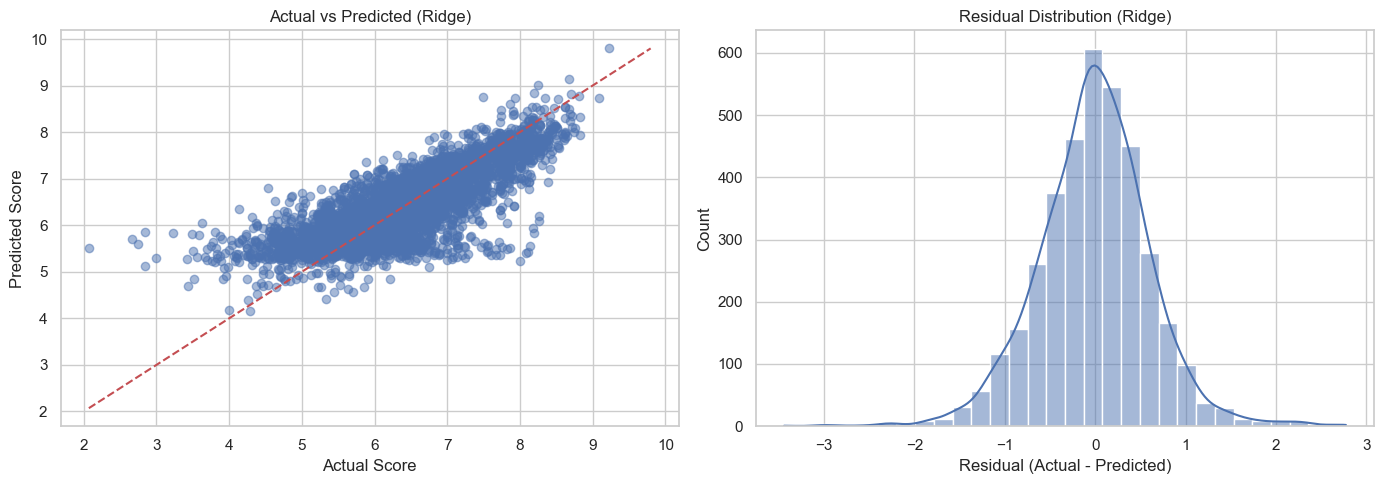

In [10]:
best_model_name = results.iloc[0]["model"]
best_pred = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_pred, alpha=0.5)
min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], "r--")
axes[0].set_title(f"Actual vs Predicted ({best_model_name})")
axes[0].set_xlabel("Actual Score")
axes[0].set_ylabel("Predicted Score")

residuals = y_test - best_pred
sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
axes[1].set_title(f"Residual Distribution ({best_model_name})")
axes[1].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

## 7. Save Trained Model and Artifacts

This section persists the best trained pipeline and metrics so you can prove model training output for submission and viva.

In [11]:
from pathlib import Path
import json
import joblib

artifacts_dir = Path.cwd() / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

best_model = pipelines[best_model_name]
model_path = artifacts_dir / "best_model_from_notebook.joblib"
results_path = artifacts_dir / "results_from_notebook.csv"
metadata_path = artifacts_dir / "metadata_from_notebook.json"

joblib.dump(best_model, model_path)
results.to_csv(results_path, index=False)

metadata = {
    "best_model": best_model_name,
    "rows_total": int(len(X)),
    "rows_train": int(len(X_train)),
    "rows_test": int(len(X_test)),
    "files": {
        "model": str(model_path),
        "results": str(results_path),
        "metadata": str(metadata_path)
    }
}

with metadata_path.open("w", encoding="utf-8") as fp:
    json.dump(metadata, fp, indent=2)

## 8. Interpretation and Discussion

Why linear regression is a valid baseline:
- It is interpretable and fast to train.
- Coefficients/weights give direction of feature impact.
- Works well as a benchmark before moving to more complex nonlinear models (Random Forest, SVM alternatives for classification task).

Why gradient descent version was included:
- `SGDRegressor` optimizes the linear regression objective iteratively.
- Useful for very large datasets or streaming settings.
- In finite small-medium tabular datasets, closed-form/solver-based `LinearRegression` or `Ridge` can be as good or better.

Possible improvements:
- Better text feature extraction (TF-IDF on synopsis/genre tokens).
- Stronger review/profile join features where user-anime mapping is available.
- Hyperparameter tuning: SVD components, Ridge alpha, SGD learning rate schedule.
- Outlier handling and robust regression variants.